In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

In [2]:
root_path = Path("/mnt/jwh83-data/Confetti")
output_dir = root_path / "output"

HUBMAP_H5AD = output_dir / "20260130_HuBMAP_Yang_annotate_with_area.h5ad"

MODEL_H5ADS = {
    "Mesmer":      output_dir / "Channel_feature" / "Merged" / "mesmer_leiden_prelim.h5ad",
    "Cellpose":    output_dir / "Channel_feature" / "Merged" / "cellpose_old_update3_leiden_prelim.h5ad",
    "CellposeSAM": output_dir / "Channel_feature" / "Merged" / "cellposeSAM_leiden_prelim.h5ad",
    "MicroSAM":    output_dir / "Channel_feature" / "Merged" / "microSAM_leiden_prelim.h5ad",
    "CellSAM":     output_dir / "Channel_feature" / "Merged" / "cellSAM_2_update_leiden_prelim.h5ad",
    "InstanSeg":   output_dir / "Channel_feature" / "Merged" / "instanseg_leiden_prelim.h5ad",
}

In [3]:
SAMPLE_COL = "sample_ID"
AREA_COL   = "area"

In [4]:
def adata_to_dataframe(adata):
    df_var = adata.to_df()
    df_obs = adata.obs
    return pd.concat([df_var, df_obs], axis=1)

def require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

def load_method_df(name, path, sample_col=SAMPLE_COL, area_col=AREA_COL):
    adata = ad.read_h5ad(path)
    df = adata_to_dataframe(adata)
    require_cols(df, [sample_col, area_col])
    df = df[[sample_col, area_col]].copy()
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df = df.dropna(subset=[sample_col, area_col])
    df["method"] = name
    return df

def summarize_counts(df, sample_col=SAMPLE_COL):
    # per-sample counts
    return df.groupby(sample_col).size()

def summarize_median_area(df, sample_col=SAMPLE_COL, area_col=AREA_COL):
    # per-sample median area
    return df.groupby(sample_col)[area_col].median()

def wilcoxon_vs_hubmap(hub_series, method_series):
    common = hub_series.index.intersection(method_series.index)
    x = method_series.loc[common].astype(float).values
    y = hub_series.loc[common].astype(float).values
    stat, p = wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
    return stat, p, common

def p_to_star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

In [5]:
hub_df = load_method_df("HuBMAP", HUBMAP_H5AD)

method_dfs = [hub_df]
for name, path in MODEL_H5ADS.items():
    method_dfs.append(load_method_df(name, path))

all_df = pd.concat(method_dfs, ignore_index=True)

# Order methods like your figure (HuBMAP first)
method_order = ["HuBMAP"] + list(MODEL_H5ADS.keys())
all_df["method"] = pd.Categorical(all_df["method"], categories=method_order, ordered=True)


/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


/tmp/ipykernel_350246/1826954060.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = all_df.groupby("method").size().reindex(method_order)


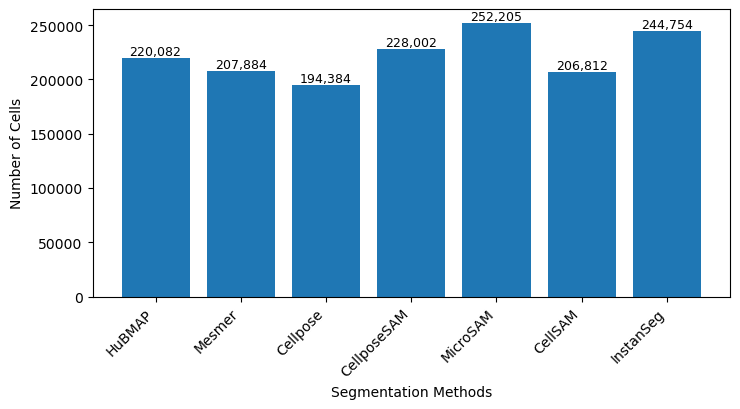

In [6]:
total_counts = all_df.groupby("method").size().reindex(method_order)

plt.figure(figsize=(7.5, 4.2))
x = np.arange(len(method_order))
bars = plt.bar(x, total_counts.values)

plt.xticks(x, method_order, rotation=45, ha="right")
plt.ylabel("Number of Cells")
plt.xlabel("Segmentation Methods")

# annotate counts
for i, v in enumerate(total_counts.values):
    plt.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

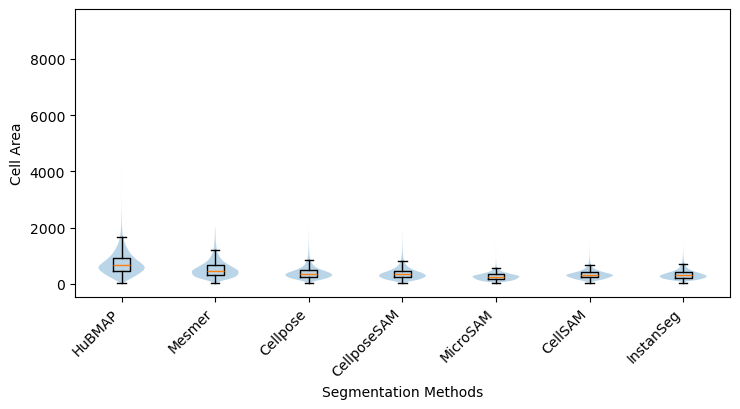

In [7]:
plt.figure(figsize=(7.5, 4.2))

data_list = [all_df.loc[all_df["method"] == m, AREA_COL].values for m in method_order]

# Violin
vp = plt.violinplot(
    data_list,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Overlay boxplot (median + IQR)
bp = plt.boxplot(
    data_list,
    widths=0.18,
    showfliers=False
)

plt.xticks(np.arange(1, len(method_order) + 1), method_order, rotation=45, ha="right")
plt.ylabel("Cell Area")
plt.xlabel("Segmentation Methods")
plt.tight_layout()
plt.show()

In [8]:
hub_area   = summarize_median_area(hub_df)
hub_counts = summarize_counts(hub_df)

test_rows_area = []
test_rows_count = []
diffs_area_long = []
diffs_count_long = []

for name in MODEL_H5ADS.keys():
    df_m = all_df.loc[all_df["method"] == name, [SAMPLE_COL, AREA_COL]].copy()

    m_area   = summarize_median_area(df_m)
    m_counts = summarize_counts(df_m)

    # paired tests vs HuBMAP
    stat_a, p_a, common_a = wilcoxon_vs_hubmap(hub_area, m_area)
    stat_c, p_c, common_c = wilcoxon_vs_hubmap(hub_counts, m_counts)

    test_rows_area.append({
        "method": name,
        "n_samples": len(common_a),
        "wilcoxon_stat": stat_a,
        "p_value": p_a,
    })
    test_rows_count.append({
        "method": name,
        "n_samples": len(common_c),
        "wilcoxon_stat": stat_c,
        "p_value": p_c,
    })

    # store paired diffs for plots (method - HuBMAP)
    da = (m_area.loc[common_a] - hub_area.loc[common_a]).rename("diff")
    for sid, val in da.items():
        diffs_area_long.append({"method": name, SAMPLE_COL: sid, "diff": float(val)})

    dc = (m_counts.loc[common_c] - hub_counts.loc[common_c]).rename("diff")
    for sid, val in dc.items():
        diffs_count_long.append({"method": name, SAMPLE_COL: sid, "diff": float(val)})

area_test_df = pd.DataFrame(test_rows_area).sort_values("p_value")
count_test_df = pd.DataFrame(test_rows_count).sort_values("p_value")

diff_area_df = pd.DataFrame(diffs_area_long)
diff_count_df = pd.DataFrame(diffs_count_long)

# Keep plotting order consistent
diff_area_df["method"] = pd.Categorical(diff_area_df["method"], categories=list(MODEL_H5ADS.keys()), ordered=True)
diff_count_df["method"] = pd.Categorical(diff_count_df["method"], categories=list(MODEL_H5ADS.keys()), ordered=True)


/tmp/ipykernel_350246/4251460492.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(sample_col)[area_col].median()
/tmp/ipykernel_350246/4251460492.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(sample_col).size()
/tmp/ipykernel_350246/4251460492.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(sample_col)[area_col].median()
/tmp/ipykernel_350246/425146049

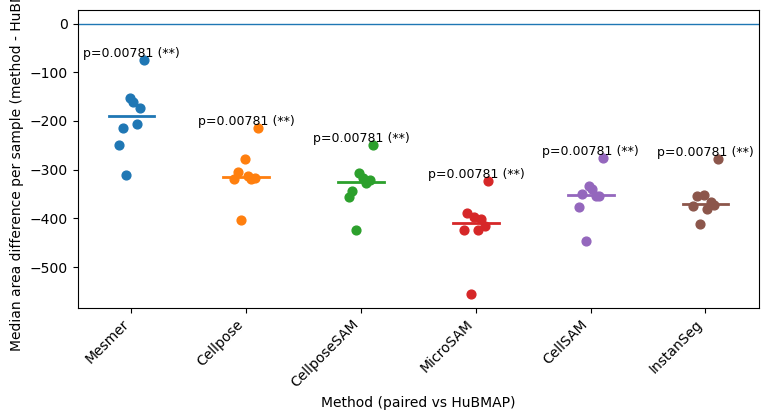

In [9]:
plt.figure(figsize=(7.8, 4.3))

methods = list(MODEL_H5ADS.keys())
xpos = np.arange(len(methods))

# Scatter per-sample diffs
for i, m in enumerate(methods):
    vals = diff_area_df.loc[diff_area_df["method"] == m, "diff"].values
    # jitter a touch for visibility (deterministic)
    jitter = (np.arange(len(vals)) - (len(vals) - 1) / 2) * 0.03
    plt.scatter(np.full_like(vals, i) + jitter, vals, s=40)

    # median line
    med = np.median(vals)
    plt.plot([i - 0.2, i + 0.2], [med, med], linewidth=2)

    # p-value annotation
    p = float(area_test_df.loc[area_test_df["method"] == m, "p_value"].iloc[0])
    star = p_to_star(p)
    # place text above points
    y_text = np.max(vals) if len(vals) else 0
    plt.text(i, y_text, f"p={p:.3g} ({star})", ha="center", va="bottom", fontsize=9)

plt.axhline(0, linewidth=1)
plt.xticks(xpos, methods, rotation=45, ha="right")
plt.ylabel("Median area difference per sample (method - HuBMAP)")
plt.xlabel("Method (paired vs HuBMAP)")
plt.tight_layout()
plt.show()

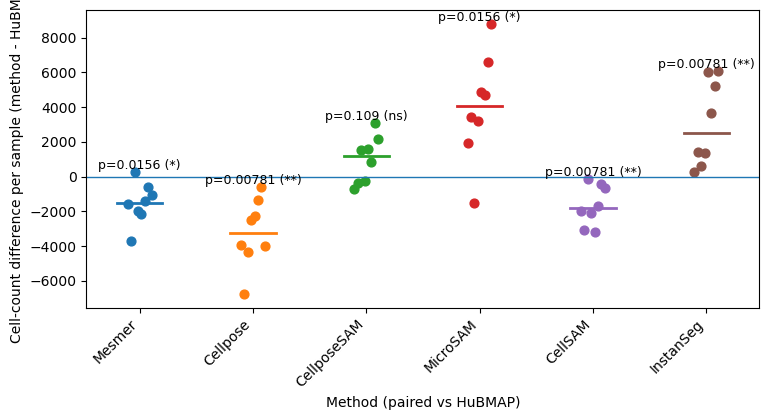


Area tests vs HuBMAP:


,method,n_samples,wilcoxon_stat,p_value
0,Mesmer,8,0.0,0.007812
1,Cellpose,8,0.0,0.007812
2,CellposeSAM,8,0.0,0.007812
3,MicroSAM,8,0.0,0.007812
4,CellSAM,8,0.0,0.007812
5,InstanSeg,8,0.0,0.007812



Count tests vs HuBMAP:


,method,n_samples,wilcoxon_stat,p_value
1,Cellpose,8,0.0,0.007812
4,CellSAM,8,0.0,0.007812
5,InstanSeg,8,0.0,0.007812
0,Mesmer,8,1.0,0.015625
3,MicroSAM,8,1.0,0.015625
2,CellposeSAM,8,6.0,0.109375


In [10]:
plt.figure(figsize=(7.8, 4.3))

for i, m in enumerate(methods):
    vals = diff_count_df.loc[diff_count_df["method"] == m, "diff"].values
    jitter = (np.arange(len(vals)) - (len(vals) - 1) / 2) * 0.03
    plt.scatter(np.full_like(vals, i) + jitter, vals, s=40)

    med = np.median(vals)
    plt.plot([i - 0.2, i + 0.2], [med, med], linewidth=2)

    p = float(count_test_df.loc[count_test_df["method"] == m, "p_value"].iloc[0])
    star = p_to_star(p)
    y_text = np.max(vals) if len(vals) else 0
    plt.text(i, y_text, f"p={p:.3g} ({star})", ha="center", va="bottom", fontsize=9)

plt.axhline(0, linewidth=1)
plt.xticks(xpos, methods, rotation=45, ha="right")
plt.ylabel("Cell-count difference per sample (method - HuBMAP)")
plt.xlabel("Method (paired vs HuBMAP)")
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: show the p-value tables
# ----------------------------
print("\nArea tests vs HuBMAP:")
display(area_test_df)

print("\nCount tests vs HuBMAP:")
display(count_test_df)

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar


In [13]:
hb = ad.read_h5ad(HUBMAP_H5AD)
hb_df = adata_to_dataframe(hb)
hb_df

,CD45RO,CD56,CD15,CD163,MUC2,CD34,CD36,aDefensin5,CD49a,HLA-DR,...,y,z,CD123,Hoechst1,DRAQ5,CDX2,cell_type_update,prelim_cell_type,sample_ID,area
803577,0.073118,-0.301631,-0.114264,1.141192,-0.213066,-0.234724,-0.198593,-0.095195,-0.427452,-0.001665,...,17.0,0.0,-0.370784,27.077135,39.022039,0.163624,CD4+ T,CD4+ T,B004-A-008,726
803578,-0.565925,-0.205546,-0.114352,-0.374752,-0.228833,-0.302481,-0.312577,-0.114157,1.902062,-0.469844,...,20.0,0.0,-0.408806,5.802395,6.453593,-0.113080,Smooth muscle,Smooth muscle,B004-A-008,668
803579,0.420288,-0.072680,-0.066818,-0.348792,0.958021,-0.175547,-0.294823,-0.101825,-0.377145,-0.326511,...,21.0,0.0,2.499677,34.465921,66.203459,2.933417,TA,TA,B004-A-008,983
803580,-0.070773,0.075276,-0.112171,0.305550,-0.200868,-0.225819,-0.252874,-0.092080,-0.275488,1.465877,...,21.0,0.0,-0.102842,15.954167,28.009375,0.099756,DC,DC,B004-A-008,960
803581,0.619267,-0.013644,-0.067793,0.096057,0.398764,-0.021867,-0.167940,-0.030520,0.362586,0.053551,...,23.0,0.0,0.529113,31.387097,58.012097,3.462033,CD8+ T,CD8+ T,B004-A-008,248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158150,-0.307824,-0.342484,0.030693,-0.159527,-0.228833,-0.322306,-0.312577,-0.119378,-0.520773,-0.344247,...,9491.0,0.0,-0.269797,12.319111,19.554667,0.753752,Stromal,Stromal,B004-A-204,1125
2158151,0.321066,-0.244903,0.263445,0.151336,-0.218318,0.027035,-0.176077,-0.089377,-0.355089,0.345467,...,9493.0,0.0,-0.090562,20.150980,34.225490,2.156543,Plasma,Plasma,B004-A-204,510
2158152,-0.434531,-0.148815,-0.063359,-0.283271,-0.097851,-0.365816,-0.311706,-0.120013,-0.523471,-0.301467,...,9499.0,0.0,-0.531758,8.034586,9.648120,-0.365875,Stromal,Stromal,B004-A-204,665
2158153,0.198842,0.119692,0.016965,0.040946,-0.219814,0.126013,-0.103515,0.148614,-0.251620,0.024046,...,9499.0,0.0,0.121086,8.567410,15.376334,2.376367,Stromal,Stromal,B004-A-204,1031


In [14]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.spatial import cKDTree
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt

In [15]:
SAMPLE_COL = "sample_ID"
X_COL = "x"
Y_COL = "y"
MAX_DIST = 10.0

/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_350246/1484354873.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sid, hub_sub in hub_df.groupby(SAMPLE_COL, sort=False):


,method,b,c,net_b_minus_c,stat,p_value
0,Mesmer,0,49634,-49634,0.0,0.0
1,Cellpose,0,62663,-62663,0.0,0.0
2,CellposeSAM,0,43343,-43343,0.0,0.0
3,MicroSAM,0,38120,-38120,0.0,0.0
4,CellSAM,0,50028,-50028,0.0,0.0
5,InstanSeg,0,44093,-44093,0.0,0.0


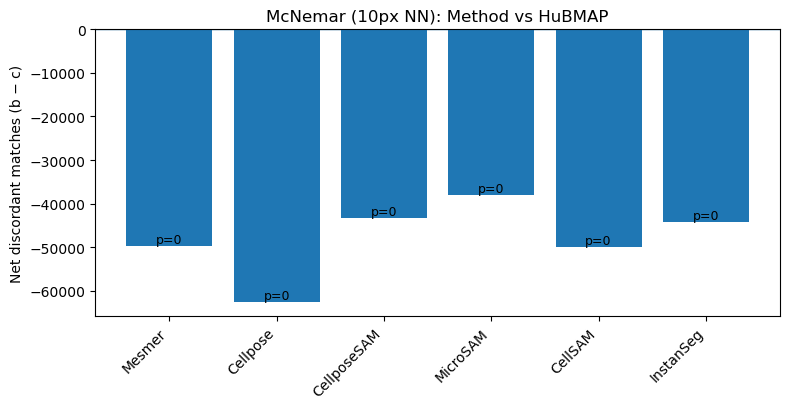

In [16]:
def adata_to_dataframe(adata):
    df = pd.concat([adata.to_df(), adata.obs.copy()], axis=1)
    df["__cell_id__"] = df.index.astype(str)
    return df

hub_adata = ad.read_h5ad(HUBMAP_H5AD)
hub_df = adata_to_dataframe(hub_adata)

method_adatas = {name: ad.read_h5ad(path) for name, path in MODEL_H5ADS.items()}
method_dfs = {name: adata_to_dataframe(a) for name, a in method_adatas.items()}

def nn_match_flags_one_to_one(hub_xy, meth_xy, max_dist):
    if hub_xy.size == 0 or meth_xy.size == 0:
        return np.zeros(hub_xy.shape[0], dtype=bool)
    tree = cKDTree(meth_xy)
    dist, j = tree.query(hub_xy, k=1)
    ok = dist <= max_dist
    if not np.any(ok):
        return np.zeros(hub_xy.shape[0], dtype=bool)
    hub_idx = np.where(ok)[0]
    meth_idx = j[ok]
    d = dist[ok]
    cand = pd.DataFrame({"hub_i": hub_idx, "meth_j": meth_idx, "dist": d})
    cand = cand.sort_values("dist").drop_duplicates("meth_j", keep="first")
    matched = np.zeros(hub_xy.shape[0], dtype=bool)
    matched[cand["hub_i"].to_numpy()] = True
    return matched

rows = []

for sid, hub_sub in hub_df.groupby(SAMPLE_COL, sort=False):
    hub_sub = hub_sub[["__cell_id__", X_COL, Y_COL]].copy()
    hub_xy = hub_sub[[X_COL, Y_COL]].to_numpy(dtype=float)
    hub_ids = hub_sub["__cell_id__"].to_numpy()
    for method, mdf in method_dfs.items():
        meth_sub = mdf.loc[mdf[SAMPLE_COL] == sid, [X_COL, Y_COL]]
        meth_xy = meth_sub.to_numpy(dtype=float)
        flags = nn_match_flags_one_to_one(hub_xy, meth_xy, MAX_DIST)
        rows.append(pd.DataFrame({"hubmap_cell_id": hub_ids, "method": method, "matched": flags.astype(int)}))

rows.append(pd.DataFrame({"hubmap_cell_id": hub_df["__cell_id__"].values, "method": "HuBMAP", "matched": 1}))
match_df = pd.concat(rows, ignore_index=True).drop_duplicates(["hubmap_cell_id", "method"], keep="first")

methods = list(MODEL_H5ADS.keys())

def mcnemar_method_vs_method(match_df, a, b):
    da = match_df[match_df["method"] == a].set_index("hubmap_cell_id")["matched"]
    db = match_df[match_df["method"] == b].set_index("hubmap_cell_id")["matched"]
    common = da.index.intersection(db.index)
    da = da.loc[common]
    db = db.loc[common]
    b01 = int(((da == 1) & (db == 0)).sum())
    c10 = int(((da == 0) & (db == 1)).sum())
    table = [[0, b01], [c10, 0]]
    res = mcnemar(table, exact=True)
    return b01, c10, float(res.statistic), float(res.pvalue)

pair_rows = []
for m in methods:
    b01, c10, stat, p = mcnemar_method_vs_method(match_df, m, "HuBMAP")
    pair_rows.append({"method": m, "b": b01, "c": c10, "net_b_minus_c": b01 - c10, "stat": stat, "p_value": p})

mcnemar_df = pd.DataFrame(pair_rows).sort_values("p_value")
display(mcnemar_df)

plt.figure(figsize=(8, 4.2))
x = np.arange(len(mcnemar_df))
plt.bar(x, mcnemar_df["net_b_minus_c"].values)
plt.axhline(0, linewidth=1)
for i, (p, v) in enumerate(zip(mcnemar_df["p_value"].values, mcnemar_df["net_b_minus_c"].values)):
    plt.text(i, v, f"p={p:.2g}", ha="center", va="bottom", fontsize=9)
plt.xticks(x, mcnemar_df["method"].values, rotation=45, ha="right")
plt.ylabel("Net discordant matches (b − c)")
plt.title(f"McNemar (10px NN): Method vs HuBMAP")
plt.tight_layout()
plt.show()